In [61]:
import pandas as pd
import json

# Get the accessions
df = pd.read_csv('../uvsx/data/curated_database/cleaned_metadata.csv')


def GetTaxonIds(df, lookups):

    taxonids = []

    for acc in df['accession']:
        acc = str(acc)

        if acc in ncbi_lookup:
            taxonids.append(ncbi_lookup[acc])
            continue

        if acc in uniprot_lookup:
            taxonids.append(uniprot_lookup[acc])
            continue

        taxonids.append(None)

    print(f"Taxon ids: {len(taxonids)}\nNumber of accessions: {len(df['accession'])}")

    return taxonids

Taxon ids: 20549
Number of accessions: 20549


In [62]:
import requests
from time import sleep
import xml.etree.ElementTree as ET

API_KEY = "eb2c0b97f55a588259931f07f1099b896207"


def fetch_taxonomy_ranked_lineage_list(taxids, batch_size=200):

    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    input_taxids = [str(t) for t in taxids if t is not None]

    results = []

    for i in range(0, len(input_taxids), batch_size):
        batch = input_taxids[i:i + batch_size]

        params = {
            "db": "taxonomy",
            "id": ",".join(batch),
            "retmode": "xml",
            "api_key": API_KEY
        }

        res = requests.get(url, params=params)
        root = ET.fromstring(res.text)

        # Build temporary lookup for this batch
        batch_lookup = {}

        for taxon in root.findall(".//Taxon"):
            taxid_node = taxon.find("TaxId")
            if taxid_node is None:
                continue

            taxid = taxid_node.text
            lineage_dict = {}

            lineage_ex = taxon.find("LineageEx")

            if lineage_ex is not None:
                for node in lineage_ex.findall("Taxon"):
                    rank_node = node.find("Rank")
                    name_node = node.find("ScientificName")

                    if rank_node is not None and name_node is not None:
                        rank = rank_node.text.lower()
                        name = name_node.text

                        if rank != "no rank":
                            lineage_dict[rank] = name

            current_rank = taxon.find("Rank")
            current_name = taxon.find("ScientificName")

            if current_rank is not None and current_name is not None:
                rank = current_rank.text.lower()
                name = current_name.text

                if rank != "no rank":
                    lineage_dict[rank] = name

            batch_lookup[taxid] = lineage_dict

        # ✅ Preserve original order + duplicates
        for t in batch:
            results.append({
                "taxid": t,
                "lineage": batch_lookup.get(t)
            })

        sleep(0.3)

    return results

In [63]:
lineages=fetch_taxonomy_ranked_lineage_list(taxonids)

In [64]:
len(lineages)
ids=[]
for i in lineages:
    ids.append(i['taxid'])

In [94]:
def FindRanks(lineages, rank):
    names = []
    for i in range(len(lineages)):
        if lineages[i] is not None:
            lineage = lineages[i].get('lineage')
            if lineage is not None:
                classification = lineage.get(rank)
            else:
                classification = None
        else:
            classification = None

        names.append(classification)
    return names



In [109]:
genera=FindRanks(lineages, 'genus')

In [110]:
def FindUniqueCounts(ranks):
    counts={}
    for rank in ranks:
        if rank not in counts.keys():
            counts[rank]=0
        if rank in counts.keys():
            counts[rank]+=1
    return counts


In [111]:
counts=FindUniqueCounts(genera)

In [112]:

import pandas as pd
import matplotlib.pyplot as plt


def PlotRankCounts(counts, threshold=100):

    df = pd.DataFrame(list(counts.items()), columns=['Virus', 'Count'])


    major = df[df['Count'] > threshold]
    minor = df[df['Count'] <= threshold]

    other_count = minor['Count'].sum()

    if other_count > 0:
        major = pd.concat(
            [major, pd.DataFrame([['Other', other_count]], columns=['Virus', 'Count'])]
        )

    major = major.sort_values(by='Count', ascending=False)

    # Create figure + axes
    fig, ax = plt.subplots()

    major.plot(kind='bar', x='Virus', y='Count', ax=ax)

    ax.set_xlabel('Genus')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()

    return fig, ax

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Genus'>)

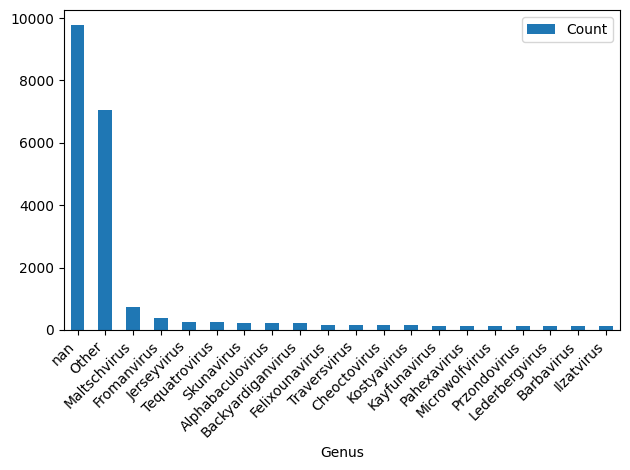

In [113]:
PlotRankCounts(counts, threshold=100)

In [56]:
from collections import defaultdict

collapse_map = {
    'subphylum': 'phylum',
    'suborder': 'order',
    'subfamily': 'family',
    'subgenus': 'genus'
}

rank_values = defaultdict(set)

for entry in lineages:
    lineage = entry.get("lineage")

    if not lineage:
        continue

    for rank, value in lineage.items():
        # collapse rank first
        new_rank = collapse_map.get(rank, rank)
        rank_values[new_rank].add(value)

# Now count unique values per collapsed rank
collapsed_counts = {rank: len(values) for rank, values in rank_values.items()}

/var/folders/7y/g8zz31hx47955l5hvty2hyzh0000gn/T/ipykernel_3220/2204193484.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['Rank'] = pd.Categorical(df['Rank'], categories=rank_order, ordered=True)


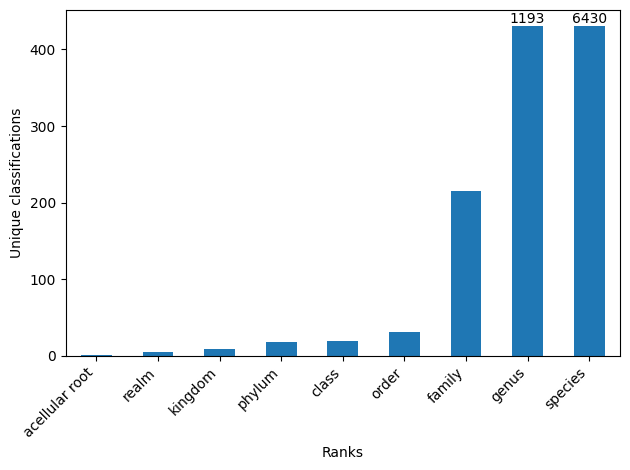

In [58]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

def PlotRanksSummary(lineages):
    collapse_map = {
        'subphylum': 'phylum',
        'suborder': 'order',
        'subfamily': 'family',
        'subgenus': 'genus'
    }

    rank_values = defaultdict(set)

    for entry in lineages:
        lineage = entry.get("lineage")
        if not lineage:
            continue

        for rank, value in lineage.items():
            new_rank = collapse_map.get(rank, rank)
            rank_values[new_rank].add(value)

    collapsed_counts = {rank: len(values) for rank, values in rank_values.items()}

    df = pd.DataFrame(list(collapsed_counts.items()), columns=['Rank', 'Count'])

    rank_order = [
        'acellular root','realm','kingdom','phylum','class','order',
        'family','genus','species'
    ]

    df['Rank'] = pd.Categorical(df['Rank'], categories=rank_order, ordered=True)
    df = df.sort_values('Rank')
    df = df[df['Rank'].notna()]

    sorted_counts = df['Count'].sort_values(ascending=False).values
    scale_value = sorted_counts[2] if len(sorted_counts) >= 3 else sorted_counts[-1]
    cap_value = scale_value * 2

    df_plot = df.copy()
    real_values = {}

    for i, row in df.iterrows():
        if row['Count'] > cap_value:
            real_values[row['Rank']] = row['Count']
            df_plot.loc[i, 'Count'] = cap_value

    # Create fig + ax
    fig, ax = plt.subplots()

    df_plot.plot(kind='bar', x='Rank', y='Count', legend=False, ax=ax)

    for i, row in df_plot.iterrows():
        rank = row['Rank']
        if rank in real_values:
            ax.text(i, cap_value, f"{real_values[rank]}",
                    ha='center', va='bottom', fontsize=10)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel("Unique classifications")
    ax.set_xlabel('Ranks')

    plt.tight_layout()

    return fig, ax

In [ ]:
print('done')